# Lista 04 de Visão Computacional

Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

Link da lista: https://drive.google.com/file/d/1RLlDFoV_hk_BUscJiveLQ8e_TXUyxZl4/view


## Importações e Funções Auxiliares


In [12]:
import os
from pathlib import Path

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report


def show_images(
    *images: np.ndarray,
    titles: list[str] | None = None,
    columns: int = 2,
    scale: int = 5,
) -> None:
    num_images = len(images)

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(num_images)]

    rows = (num_images + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        if img is None:
            ax.axis("off")
            continue
        img_disp = img
        ax.imshow(img_disp, cmap="gray" if img_disp.ndim == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

## Questão 1

Nesta questão, implementamos


In [11]:
# https://umatechnology.org/how-to-train-an-object-detection-engine-with-hog-in-opencv/

from sklearn.metrics import confusion_matrix


IMG_SIZE = 128


def extract_features(hog: cv.HOGDescriptor, base_dir: Path):
    data = []
    for label, category in enumerate(base_dir.iterdir()):
        for file in os.listdir(category):
            img_path = os.path.join(category, file)
            img = cv.imread(img_path, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(
                {
                    "features": hog.compute(img).flatten(),
                    "label": label,
                    "path": img_path,
                }
            )
    return pd.DataFrame(data)


def train_svm(features: pd.DataFrame):
    df_train, df_test = train_test_split(
        features, test_size=0.30, stratify=features["label"], random_state=42
    )

    X_train = np.stack(df_train['features'].to_numpy())
    y_train = df_train['label'].to_numpy()
    X_test = np.stack(df_test['features'].to_numpy())

    svm_model = SVC(kernel='linear')
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    return y_pred, df_test

def generate_cm(y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       150
           1       0.87      0.86      0.87       150

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300



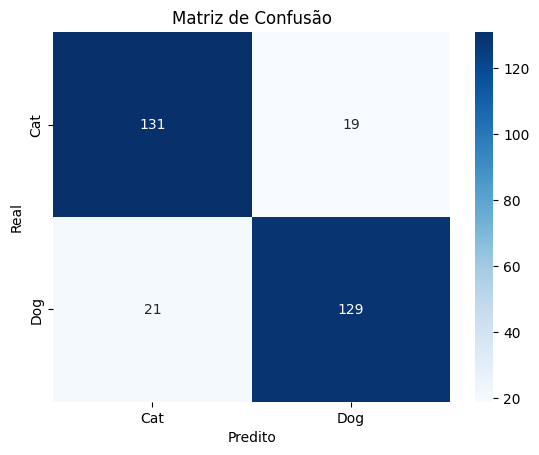

In [16]:
base_dir = "animals"
categories = ['Cat', 'Dog']
hog = cv.HOGDescriptor(
    _winSize=(IMG_SIZE, IMG_SIZE),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9,
)
# window size: (64,64)
# block size: (32, 32)
# block stride: (16, 16)
# cell size: (16, 16)
# number of bins: 9

feats = extract_features(hog, Path(base_dir))
y_pred, df_test = train_svm(feats)


result = classification_report(df_test['label'], y_pred)
print(result)
generate_cm(df_test['label'], y_pred, categories)

